In [1]:
# ============================================================
# H5 - PATIENT SEX vs VISIT DISPOSITION
# ============================================================
# Research question : Is there a significant association between patient sex and visit disposition?
# Null hypothesis   : Patient sex and visit disposition are independent.
# Alternative       : Patient sex and visit disposition are associated.
# Method            : Pearson chi-square test of independence on the visit-weighted contingency table
#
# Cell counts are SUMMED ED VISITS, not aggregate row counts.
#
# The test itself is NOT reimplemented here. It is imported from
# backend.analytics.statistics.weighted, the same engine the API serves, so this
# notebook and the production endpoint cannot report different numbers.

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Resolve the project root so the notebook runs from any working directory.
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "backend").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "Explorer Dataset"
CLEAN_DIR = RAW_DIR / "cleaned"
WORKBOOK = PROJECT_ROOT / "data" / "cleaned dataset" / "Explanatory_and_Predictive_ED_Analytics_Dataset.xlsx"

ALPHA = 0.05

print("Project root :", PROJECT_ROOT)
print("Alpha        :", ALPHA)

Project root : C:\Users\amitd\Downloads\Desktoppp\UNF\UNF Assignment _ Notes_Class Practise\Term 5\Capstone\Github\Capstone_Project-DAMO-6994-
Alpha        : 0.05


In [3]:
# Prefer the cleaned copy written by data/Explorer Dataset/Explorer_Dataset_Cleaning.ipynb.
SOURCE = CLEAN_DIR / "Visit_Disposition.csv"

if not SOURCE.exists():
    SOURCE = RAW_DIR / "Visit_Disposition.csv"

df = pd.read_csv(SOURCE)

print("Source file :", SOURCE.relative_to(PROJECT_ROOT))
print("Shape       :", df.shape)
print("Cleaned copy:", SOURCE.parent == CLEAN_DIR)

Source file : data\Explorer Dataset\cleaned\Visit_Disposition.csv
Shape       : (936, 13)
Cleaned copy: True


In [4]:
print("FIRST 10 ROWS")
print("-" * 80)

display(df.head(10))

FIRST 10 ROWS
--------------------------------------------------------------------------------


,fiscal_year,fiscal_year_start,sex,visit_disposition,admission_flag,admission_status,age_group,population_category,ed_visits,median_los_minutes,median_los_hours,erbi,is_suppressed
0,2021-2022,2021,Female,Admitted,1,Admitted,0-19,Pediatric & Youth,61448,450.0,7.5,27651600,0
1,2021-2022,2021,Female,Admitted,1,Admitted,20-44,Young Adult,135970,702.0,11.7,95450940,0
2,2021-2022,2021,Female,Admitted,1,Admitted,45-64,Middle Adult,154636,792.0,13.2,122471712,0
3,2021-2022,2021,Female,Admitted,1,Admitted,65+,Older Adult,423379,966.0,16.1,408984114,0
4,2021-2022,2021,Male,Admitted,1,Admitted,0-19,Pediatric & Youth,61089,420.0,7.0,25657380,0
5,2021-2022,2021,Male,Admitted,1,Admitted,20-44,Young Adult,135841,720.0,12.0,97805520,0
6,2021-2022,2021,Male,Admitted,1,Admitted,45-64,Middle Adult,197560,762.0,12.7,150540720,0
7,2021-2022,2021,Male,Admitted,1,Admitted,65+,Older Adult,403171,906.0,15.1,365272926,0
8,2021-2022,2021,Female,Death,0,Not Admitted,0-19,Pediatric & Youth,176,36.0,0.6,6336,0
9,2021-2022,2021,Female,Death,0,Not Admitted,20-44,Young Adult,452,42.0,0.7,18984,0


In [5]:
print("COLUMN NAMES AND TYPES")
print("-" * 80)

display(pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing": [int(df[c].isna().sum()) for c in df.columns],
}))

COLUMN NAMES AND TYPES
--------------------------------------------------------------------------------


,Column,Data_Type,Missing
0,fiscal_year,str,0
1,fiscal_year_start,int64,0
2,sex,str,0
3,visit_disposition,str,0
4,admission_flag,int64,0
5,admission_status,str,0
6,age_group,str,0
7,population_category,str,0
8,ed_visits,int64,0
9,median_los_minutes,float64,0


In [6]:
print("DATA QUALITY CHECKS")
print("-" * 80)

print(f"Rows              : {len(df):,}")
print(f"Duplicate rows    : {df.duplicated().sum():,}")
print(f"Total missing     : {df.isna().sum().sum():,}")

if "ed_visits" in df.columns:
    print(f"ED visits <= 0    : {(df['ed_visits'] <= 0).sum():,}")
    print(f"Total ED visits   : {df['ed_visits'].sum():,.0f}")

if "median_los_minutes" in df.columns:
    print(f"LOS < 0           : {(df['median_los_minutes'] < 0).sum():,}")

DATA QUALITY CHECKS
--------------------------------------------------------------------------------
Rows              : 936
Duplicate rows    : 0
Total missing     : 0
ED visits <= 0    : 0
Total ED visits   : 175,762,944
LOS < 0           : 0


In [7]:
from backend.analytics.statistics.chi_square import chi_square_test
from backend.analytics.statistics.weighted import chi2_sf

print("Chi-square engine imported from backend.analytics.statistics")

Chi-square engine imported from backend.analytics.statistics


In [8]:
# The contingency table must be built from VISIT COUNTS. Counting aggregate rows
# instead would weight a 1,000-visit cell the same as a 1,000,000-visit cell.
h5_df = df.dropna(subset=["sex", "visit_disposition", "ed_visits"]).copy()
h5_df = h5_df[h5_df["ed_visits"] > 0]
h5_df = h5_df[h5_df["visit_disposition"].astype(str).str.strip() != "Unknown"]

contingency = (
    h5_df.pivot_table(
        index="sex",
        columns="visit_disposition",
        values="ed_visits",
        aggfunc="sum",
        fill_value=0,
    )
    .astype("int64")
)

print("H5 CONTINGENCY TABLE (SUMMED ED VISITS)")
print("=" * 80)

display(contingency)

print(f"Total visits represented: {contingency.to_numpy().sum():,}")

H5 CONTINGENCY TABLE (SUMMED ED VISITS)


visit_disposition,Admitted,Death,Discharged,Intra-Facility Transfer,Left Without Being Seen,Transferred
sex,,,,,,
Female,9048750,68750,75721642,486574,4234749,1344255
Male,8955470,113253,69523898,422810,4257611,1442011


Total visits represented: 175,619,773


In [9]:
# Chi-square requires every expected cell frequency to be at least 5. With visit
# counts in the millions this is satisfied by an enormous margin, but the check is
# what licenses the test, so it is performed rather than assumed.
observed = contingency.to_numpy()
row_sums = observed.sum(axis=1, keepdims=True)
col_sums = observed.sum(axis=0, keepdims=True)
total = observed.sum()

expected = row_sums @ col_sums / total

expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

print("EXPECTED FREQUENCIES UNDER INDEPENDENCE")
print("-" * 80)

display(expected_df.round(1))

below = int((expected < 5).sum())

print(f"Cells with expected frequency < 5: {below}")
print("Assumption met:", below == 0)

EXPECTED FREQUENCIES UNDER INDEPENDENCE
--------------------------------------------------------------------------------


visit_disposition,Admitted,Death,Discharged,Intra-Facility Transfer,Left Without Being Seen,Transferred
sex,,,,,,
Female,9319386.7,94208.8,75182338.1,470717.5,4395835.4,1442233.6
Male,8684833.3,87794.2,70063201.9,438666.5,4096524.6,1344032.4


Cells with expected frequency < 5: 0
Assumption met: True


In [10]:
chi2, dof, p_value = chi_square_test(observed.tolist())

print("H5 - PEARSON CHI-SQUARE TEST OF INDEPENDENCE")
print("-" * 80)
print(f"Chi-square statistic : {chi2:,.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"P-value              : {p_value:.10g}")
print(f"Total visits (N)     : {total:,}")

H5 - PEARSON CHI-SQUARE TEST OF INDEPENDENCE
--------------------------------------------------------------------------------
Chi-square statistic : 65,718.7396
Degrees of freedom   : 5
P-value              : 0
Total visits (N)     : 175,619,773


In [11]:
print("=" * 80)
print("H5 HYPOTHESIS DECISION")
print("=" * 80)
print("Significance level (alpha):", ALPHA)
print(f"P-value: {p_value:.10g}")
print()

if p_value < ALPHA:
    print("Decision: REJECT H0")
    print()
    print("Conclusion:")
    print("Patient sex and visit disposition are not independent; disposition")
    print("proportions differ between sexes.")
else:
    print("Decision: FAIL TO REJECT H0")
    print()
    print("Conclusion:")
    print("There is insufficient evidence of an association between patient sex and")
    print("visit disposition.")

H5 HYPOTHESIS DECISION
Significance level (alpha): 0.05
P-value: 0

Decision: REJECT H0

Conclusion:
Patient sex and visit disposition are not independent; disposition
proportions differ between sexes.


In [12]:
# Cramer's V rescales chi-square to [0, 1] so the association can be judged on
# strength rather than on a p-value that any large N would drive to zero.
k = min(observed.shape) - 1
cramers_v = np.sqrt(chi2 / (total * k)) if k > 0 and total > 0 else 0.0

print("H5 EFFECT SIZE")
print("-" * 80)
print(f"Cramer's V: {cramers_v:.6f}")
print()

if cramers_v < 0.1:
    band = "Negligible"
elif cramers_v < 0.3:
    band = "Small"
elif cramers_v < 0.5:
    band = "Medium"
else:
    band = "Large"

print(f"Magnitude: {band}")
print()
print(f"With N = {total:,}, statistical significance is close to automatic.")
print("Cramer's V is the figure that carries practical meaning.")

H5 EFFECT SIZE
--------------------------------------------------------------------------------
Cramer's V: 0.019345

Magnitude: Negligible

With N = 175,619,773, statistical significance is close to automatic.
Cramer's V is the figure that carries practical meaning.


In [13]:
h5_result_table = pd.DataFrame({
    "Hypothesis": ["H5"],
    "Research_Question": ["Is patient sex associated with visit disposition?"],
    "Test": ["Pearson Chi-Square Test of Independence"],
    "Chi_Square": [chi2],
    "Degrees_of_Freedom": [dof],
    "N_Visits": [int(total)],
    "P_Value": [p_value],
    "Cramers_V": [cramers_v],
    "Alpha": [ALPHA],
    "Decision": ["Reject H0" if p_value < ALPHA else "Fail to Reject H0"],
})

display(h5_result_table)

,Hypothesis,Research_Question,Test,Chi_Square,Degrees_of_Freedom,N_Visits,P_Value,Cramers_V,Alpha,Decision
0,H5,Is patient sex associated with visit disposition?,Pearson Chi-Square Test of Independence,65718.7396,5,175619773,0.0,0.019345,0.05,Reject H0


DISPOSITION MIX WITHIN EACH SEX (%)


--------------------------------------------------------------------------------


visit_disposition,Admitted,Death,Discharged,Intra-Facility Transfer,Left Without Being Seen,Transferred
sex,,,,,,
Female,9.954,0.076,83.298,0.535,4.658,1.479
Male,10.571,0.134,82.068,0.499,5.026,1.702


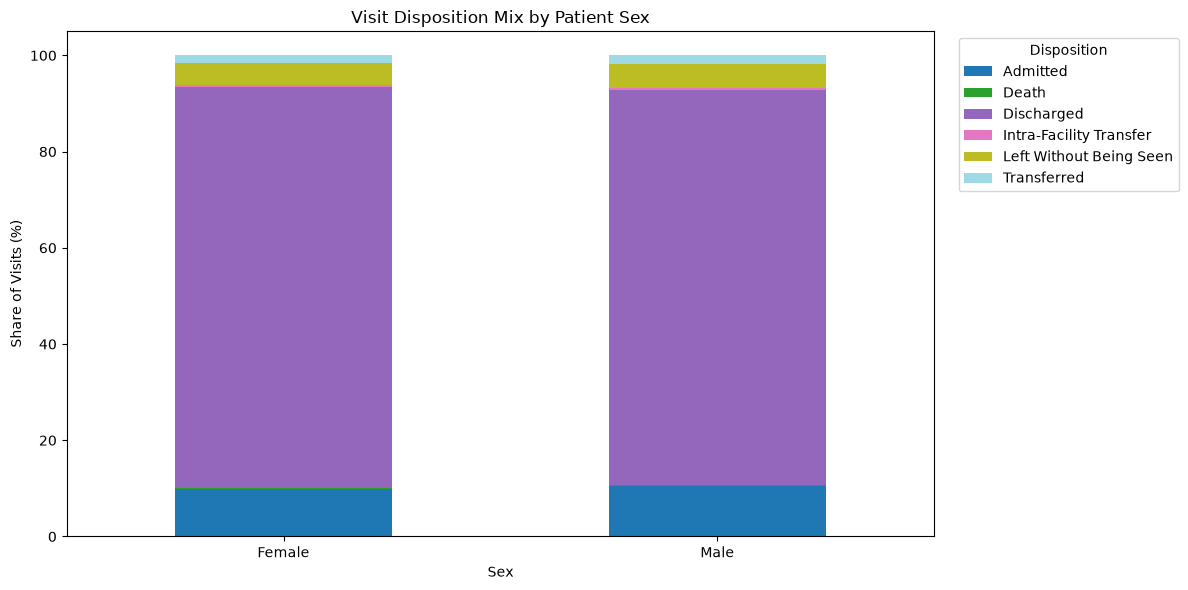

In [14]:
# Disposition mix within each sex. Row-normalising is the honest comparison, since
# the two sexes contribute different total visit volumes.
proportions = contingency.div(contingency.sum(axis=1), axis=0) * 100

print("DISPOSITION MIX WITHIN EACH SEX (%)")
print("-" * 80)

display(proportions.round(3))

fig, ax = plt.subplots(figsize=(12, 6))

proportions.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")

ax.set_xlabel("Sex")
ax.set_ylabel("Share of Visits (%)")
ax.set_title("Visit Disposition Mix by Patient Sex")
ax.legend(title="Disposition", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

STANDARDISED RESIDUALS
--------------------------------------------------------------------------------
Values beyond +/- 2 mark cells contributing most to the association.



visit_disposition,Admitted,Death,Discharged,Intra-Facility Transfer,Left Without Being Seen,Transferred
sex,,,,,,
Female,-88.65,-82.95,62.20,23.11,-76.83,-81.59
Male,91.83,85.92,-64.43,-23.94,79.59,84.51


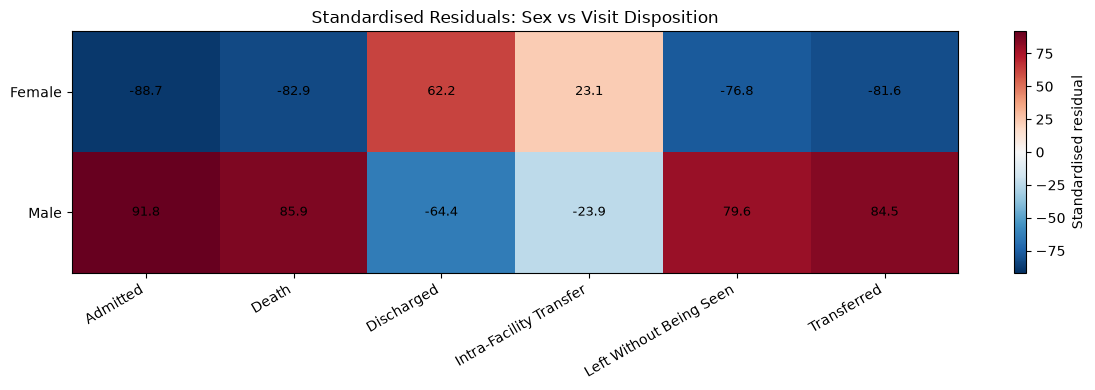

In [15]:
# Standardised (Pearson) residuals localise the association: which cells drive chi-square.
residuals = (observed - expected) / np.sqrt(expected)

residual_df = pd.DataFrame(residuals, index=contingency.index, columns=contingency.columns)

print("STANDARDISED RESIDUALS")
print("-" * 80)
print("Values beyond +/- 2 mark cells contributing most to the association.")
print()

display(residual_df.round(2))

fig, ax = plt.subplots(figsize=(12, 4))

limit = np.abs(residuals).max()
im = ax.imshow(residuals, cmap="RdBu_r", aspect="auto", vmin=-limit, vmax=limit)

ax.set_xticks(range(len(contingency.columns)))
ax.set_xticklabels(contingency.columns, rotation=30, ha="right")
ax.set_yticks(range(len(contingency.index)))
ax.set_yticklabels(contingency.index)
ax.set_title("Standardised Residuals: Sex vs Visit Disposition")

for i in range(residuals.shape[0]):
    for j in range(residuals.shape[1]):
        ax.text(j, i, f"{residuals[i, j]:.1f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, label="Standardised residual")

plt.tight_layout()
plt.show()

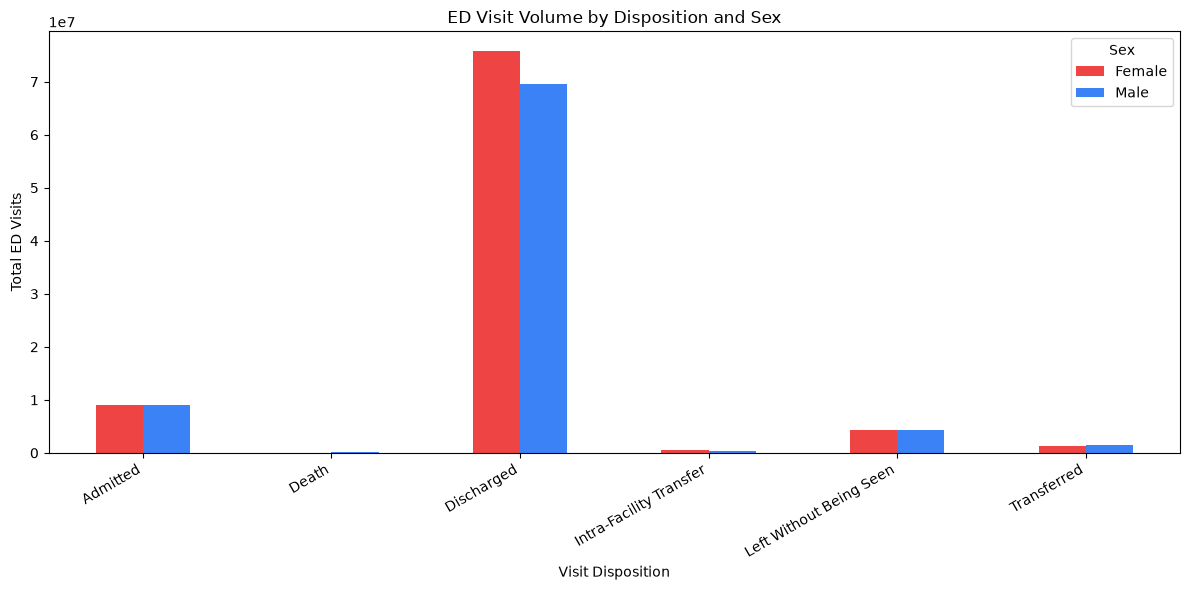

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

contingency.T.plot(kind="bar", ax=ax, color=["#EF4444", "#3B82F6"])

ax.set_xlabel("Visit Disposition")
ax.set_ylabel("Total ED Visits")
ax.set_title("ED Visit Volume by Disposition and Sex")
ax.legend(title="Sex")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

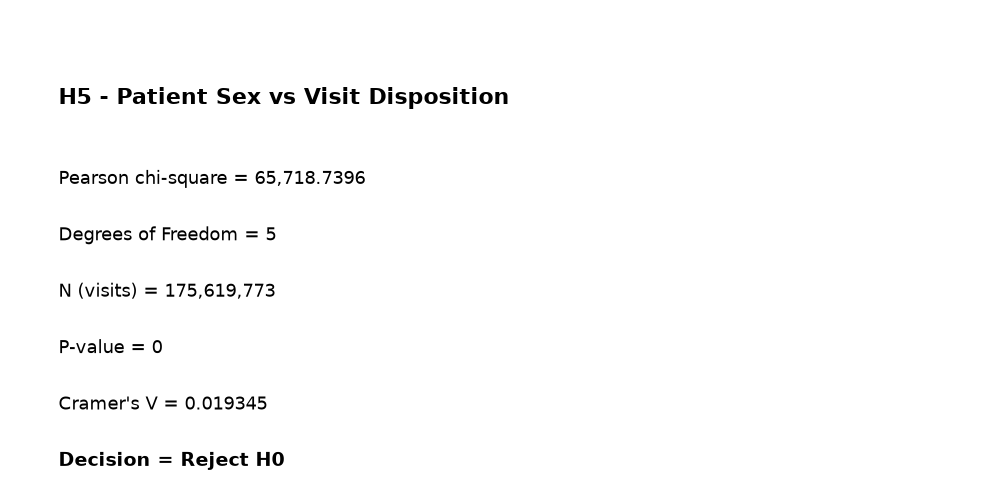

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

decision = "Reject H0" if p_value < ALPHA else "Fail to Reject H0"

ax.text(0.05, 0.80, "H5 - Patient Sex vs Visit Disposition", fontsize=16, fontweight="bold")
ax.text(0.05, 0.63, f"Pearson chi-square = {chi2:,.4f}", fontsize=13)
ax.text(0.05, 0.51, f"Degrees of Freedom = {dof}", fontsize=13)
ax.text(0.05, 0.39, f"N (visits) = {int(total):,}", fontsize=13)
ax.text(0.05, 0.27, f"P-value = {p_value:.6g}", fontsize=13)
ax.text(0.05, 0.15, f"Cramer's V = {cramers_v:.6f}", fontsize=13)
ax.text(0.05, 0.03, f"Decision = {decision}", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()